# Text associations

Associations between normalized reading times on the **text regions**
(distractor / critical / outside) and on the **answers & question**
(A / B / C / D / question), for RT and TFD.

All of the computation lives in `src/statistics/RT_correlations/`:

| module | what |
| --- | --- |
| `columns` | which columns form the rows/cols of a map, and their labels |
| `data` | loading the all-participants and per-group feature frames |
| `correlations` | the maps: pooled r, and per-participant r tested against 0 |
| `comparisons` | cells against each other, and groups against groups |
| `bootstrap` | cluster bootstrap of the pooled r |
| `plots` | annotated heatmaps and tidy tables |
| `report` | the one-call helpers used below |
| `proportions` | the same maps for dwell *proportions* (share of a screen's dwell time) rather than reading times |

Data: `L1_model_ready_all_features.csv` (`READY_ALL_FEATURES_PATH`), plus the
per-group files built on first use by `load_group_features()`. The proportion
section additionally reads the text-side shares from
`L1_paragraph_span_features.csv` (`PARAGRAPH_SPAN_FEATURES_PATH`).

In [25]:
from pathlib import Path
import sys

PROJECT_ROOT = Path.cwd().parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

import pandas as pd
import matplotlib.pyplot as plt

from src.data_paths import READY_ALL_FEATURES_PATH
from src.statistics.RT_correlations import (
    load_all_features,
    load_group_features,
    metric_map_stats,
    group_map_stats,
    plot_maps,
    plot_pooled_maps,
    shared_vmax,
    plot_contrasts,
    summarise_map,
    region_contrasts,
    reference_contrasts,
    group_contrast,
    compare_cells,
    bootstrap_maps,
    group_bootstrap_maps,
    plot_bootstrap_maps,
    map_cell,
)

# Cached model-ready features; pass rebuild=True to regenerate them from the
# processed CSVs.
df = load_all_features()
group_dfs = load_group_features()

all: (19436, 214)
hunters: (9719, 214)
gatherers: (9717, 214)


## Correlations

### The maps, as originally plotted

Plain pooled Pearson r over all ~19k trials, fixed [-1, 1] colour scale. Kept
for reference -- everything below argues that this view is misleading on both
counts.

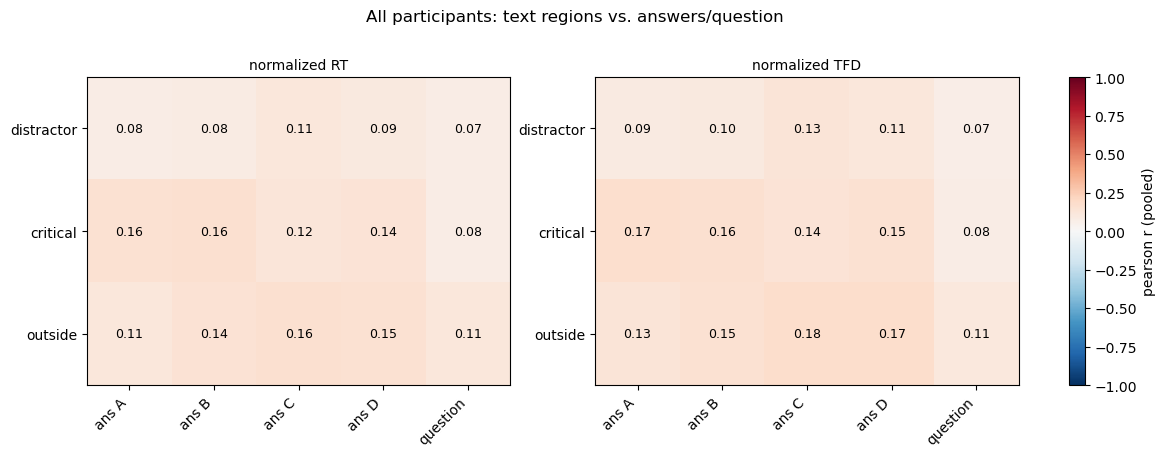

(<Figure size 1300x400 with 3 Axes>,
 array([<Axes: title={'center': 'normalized RT'}>,
        <Axes: title={'center': 'normalized TFD'}>], dtype=object))

In [26]:
plot_pooled_maps(df, "All participants", method="pearson")

### Significance

Trials are nested in participants (360 x 54) and in texts, so a p-value that
assumes ~19k independent rows would call r = 0.014 significant; the effective n
is closer to the number of participants. The tests use the **participant as the
unit of analysis**:

| question | test | function |
| --- | --- | --- |
| is a cell different from 0? | per-participant r -> Fisher z -> one-sample t-test across the 360 participants | `metric_map_stats` |
| are two cells different from each other? | paired t-test on the within-participant difference of z (the pairing absorbs the dependence between two correlations that share a variable, which Steiger's / Williams' test handles for i.i.d. data) | `region_contrasts`, `compare_cells` |
| do hunters and gatherers differ? | Welch two-sample t-test on the per-participant z (disjoint sets of 180 participants) | `group_contrast` |

p-values are Benjamini-Hochberg corrected across the 15 cells of a map. The
default is Spearman: the per-word RTs have skew up to ~40, so Pearson is driven
by a handful of outlier trials.

The estimand also changes. `r_pooled` mixes within- and between-participant
variance -- part of it is just "some people read slowly everywhere". The
participant-level `r` is the within-participant association, and it runs about
half the pooled value here.

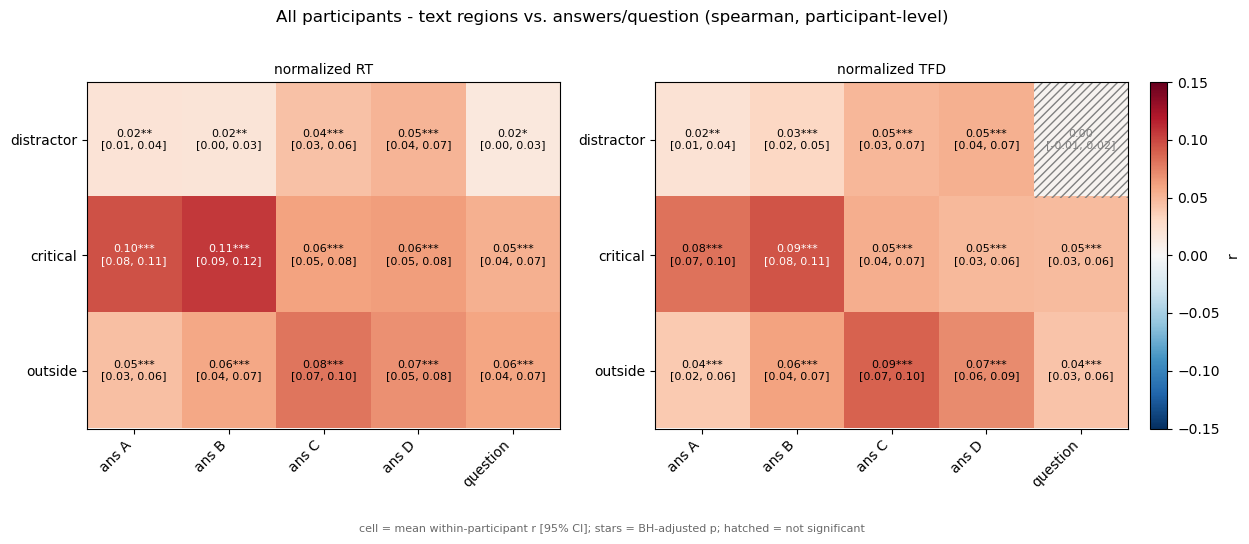

(<Figure size 1400x450 with 3 Axes>,
 array([<Axes: title={'center': 'normalized RT'}>,
        <Axes: title={'center': 'normalized TFD'}>], dtype=object))

In [27]:
stats_all = metric_map_stats(df)          # {"RT": {...}, "TFD": {...}}, spearman
plot_maps(stats_all, "All participants", show_ci=True)

In [28]:
# Per-cell numbers behind the map: participant-level r with CI, effect size, t,
# p, BH-adjusted p, and the pooled r for comparison.
summarise_map(stats_all["RT"]).round(4)

,row,col,n,r,ci_low,ci_high,d,t,p,p_adj,stars,r_pooled
0,critical,ans B,360,0.1055,0.0905,0.1205,0.7234,13.7265,0.0000,0.0000,***,0.2135
1,critical,ans A,360,0.0951,0.0803,0.1099,0.6634,12.5880,0.0000,0.0000,***,0.2260
2,outside,ans C,360,0.0804,0.0652,0.0955,0.5483,10.4033,0.0000,0.0000,***,0.2418
3,outside,ans D,360,0.0683,0.0528,0.0838,0.4555,8.6434,0.0000,0.0000,***,0.2367
4,critical,ans C,360,0.0609,0.0463,0.0754,0.4328,8.2111,0.0000,0.0000,***,0.1832
5,critical,ans D,360,0.0628,0.0474,0.0781,0.4236,8.0380,0.0000,0.0000,***,0.1997
6,outside,ans B,360,0.0582,0.0431,0.0732,0.3989,7.5695,0.0000,0.0000,***,0.2206
7,outside,question,360,0.0588,0.0430,0.0745,0.3861,7.3263,0.0000,0.0000,***,0.0922
8,critical,question,360,0.0532,0.0375,0.0688,0.3522,6.6819,0.0000,0.0000,***,0.0848
9,distractor,ans D,360,0.0506,0.0353,0.0659,0.3421,6.4907,0.0000,0.0000,***,0.1774


### Cells against each other

`region_contrasts` runs the structured set -- within each answer/question
column, the three text regions pairwise (15 tests, rather than all 105
unordered pairs of the map).

In [29]:
region_contrasts(stats_all, "RT").round(4)

,cell_a,cell_b,n,r_a,r_b,delta_r,delta_z,ci_low,ci_high,t,p,d,p_adj,sig,stars
0,RT_normalized_distractor ~ RT_normalized_answer_B,RT_normalized_critical ~ RT_normalized_answer_B,360,0.0199,0.1055,-0.0857,-0.0861,-0.1059,-0.0663,-8.5463,0.0000,-0.4504,0.0000,True,***
1,RT_normalized_distractor ~ RT_normalized_answer_A,RT_normalized_critical ~ RT_normalized_answer_A,360,0.0208,0.0951,-0.0743,-0.0746,-0.0941,-0.0552,-7.5567,0.0000,-0.3983,0.0000,True,***
2,RT_normalized_critical ~ RT_normalized_answer_A,RT_normalized_outside ~ RT_normalized_answer_A,360,0.0951,0.0456,0.0496,0.0498,0.0300,0.0696,4.9512,0.0000,0.2610,0.0000,True,***
3,RT_normalized_critical ~ RT_normalized_answer_B,RT_normalized_outside ~ RT_normalized_answer_B,360,0.1055,0.0582,0.0474,0.0477,0.0289,0.0665,4.9794,0.0000,0.2624,0.0000,True,***
4,RT_normalized_distractor ~ RT_normalized_question,RT_normalized_outside ~ RT_normalized_question,360,0.0163,0.0588,-0.0425,-0.0425,-0.0604,-0.0247,-4.6890,0.0000,-0.2471,0.0000,True,***
5,RT_normalized_distractor ~ RT_normalized_answer_C,RT_normalized_outside ~ RT_normalized_answer_C,360,0.0436,0.0804,-0.0368,-0.0369,-0.0535,-0.0204,-4.3990,0.0000,-0.2318,0.0000,True,***
6,RT_normalized_distractor ~ RT_normalized_answer_B,RT_normalized_outside ~ RT_normalized_answer_B,360,0.0199,0.0582,-0.0383,-0.0384,-0.0560,-0.0207,-4.2742,0.0000,-0.2253,0.0001,True,***
7,RT_normalized_distractor ~ RT_normalized_question,RT_normalized_critical ~ RT_normalized_question,360,0.0163,0.0532,-0.0369,-0.0369,-0.0574,-0.0164,-3.5411,0.0005,-0.1866,0.0008,True,***
8,RT_normalized_distractor ~ RT_normalized_answer_A,RT_normalized_outside ~ RT_normalized_answer_A,360,0.0208,0.0456,-0.0248,-0.0248,-0.0424,-0.0071,-2.7630,0.0060,-0.1456,0.0100,True,*
9,RT_normalized_critical ~ RT_normalized_answer_C,RT_normalized_outside ~ RT_normalized_answer_C,360,0.0609,0.0804,-0.0195,-0.0196,-0.0383,-0.0009,-2.0636,0.0398,-0.1088,0.0555,False,.


In [30]:
# Arbitrary pairs, when a specific comparison is the point.
compare_cells(
    stats_all["RT"]["z"],
    [
        (map_cell("critical", "answer_A"), map_cell("critical", "question")),
        (map_cell("critical", "answer_A"), map_cell("distractor", "answer_D")),
    ],
).round(4)

,cell_a,cell_b,n,r_a,r_b,delta_r,delta_z,ci_low,ci_high,t,p,d,p_adj,sig,stars
0,RT_normalized_critical ~ RT_normalized_answer_A,RT_normalized_critical ~ RT_normalized_question,360,0.0951,0.0532,0.0419,0.0422,0.0223,0.0620,4.1781,0.0,0.2202,0.0,True,***
1,RT_normalized_critical ~ RT_normalized_answer_A,RT_normalized_distractor ~ RT_normalized_answer_D,360,0.0951,0.0506,0.0446,0.0448,0.0245,0.0651,4.3391,0.0,0.2287,0.0,True,***


### Hunters vs. gatherers

Same maps per group, then a between-group test of every cell.

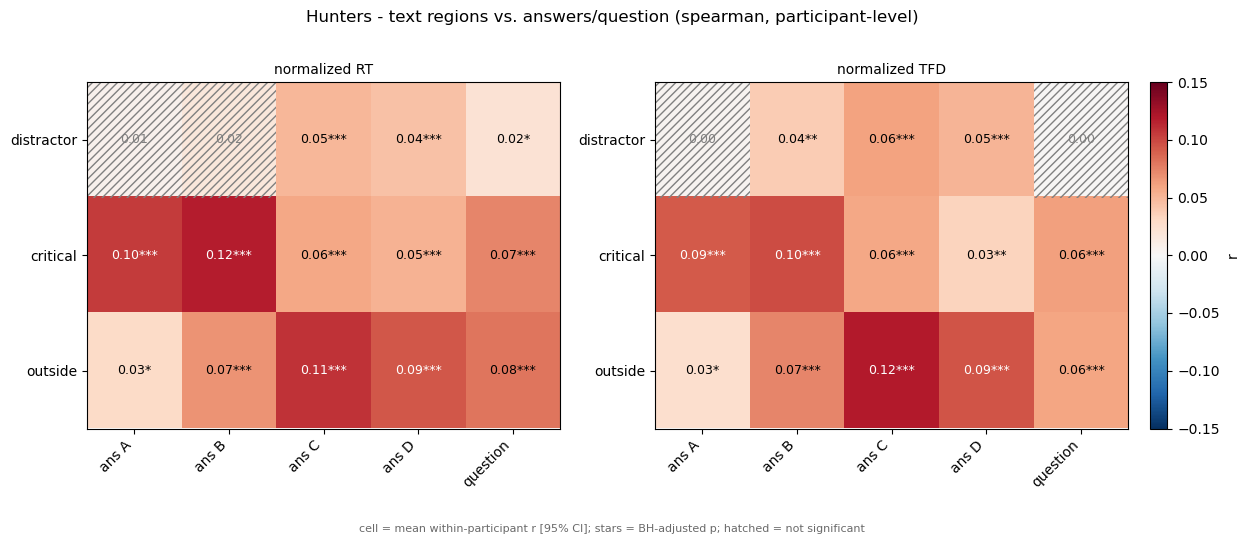

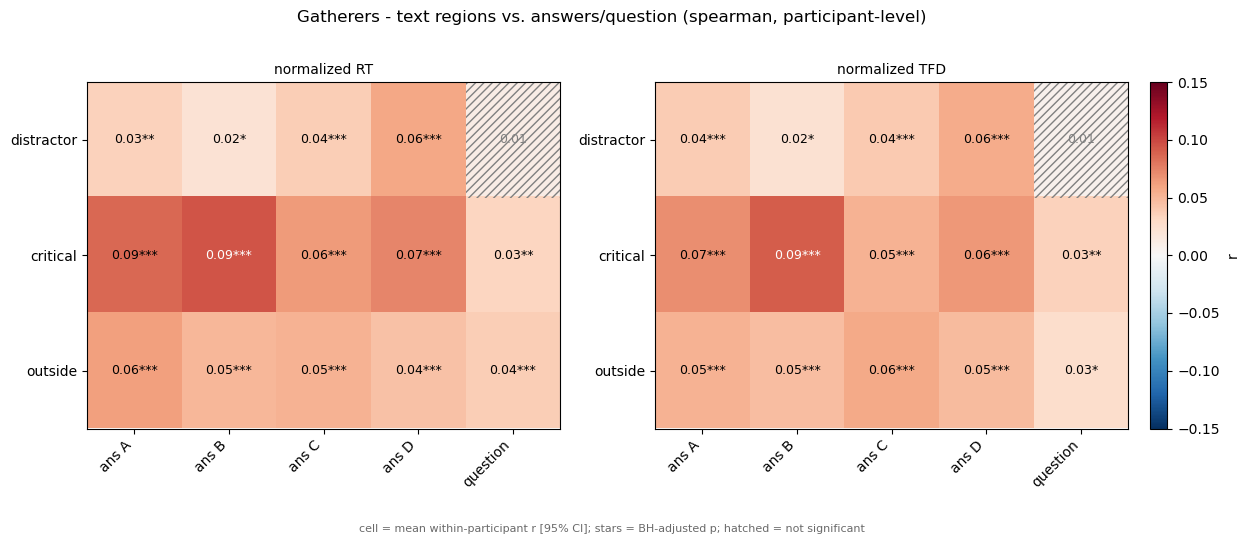

In [31]:
stats_by_group = group_map_stats(group_dfs)

# One colour scale across both figures, otherwise each auto-scales to its own
# range and the same colour means different things in the two.
vmax = shared_vmax(stats_by_group)
for name, st in stats_by_group.items():
    plot_maps(st, name.capitalize(), vmax=vmax)

In [32]:
group_contrast(stats_by_group, "RT").round(4)

,row,col,n_hunters,n_gatherers,r_hunters,r_gatherers,delta_r,delta_z,ci_low,ci_high,t,p,d,p_adj,sig,stars
0,RT_normalized_distractor,RT_normalized_answer_A,180,180,0.0069,0.0346,-0.0277,-0.0277,-0.0573,0.0018,-1.8469,0.0656,-0.1947,0.1640,False,
1,RT_normalized_distractor,RT_normalized_answer_B,180,180,0.0175,0.0222,-0.0047,-0.0047,-0.0346,0.0252,-0.3084,0.7579,-0.0325,0.7579,False,
2,RT_normalized_distractor,RT_normalized_answer_C,180,180,0.0501,0.0370,0.0130,0.0131,-0.0173,0.0434,0.8455,0.3984,0.0891,0.4980,False,
3,RT_normalized_distractor,RT_normalized_answer_D,180,180,0.0435,0.0576,-0.0141,-0.0142,-0.0448,0.0165,-0.9081,0.3644,-0.0957,0.4969,False,
4,RT_normalized_distractor,RT_normalized_question,180,180,0.0215,0.0112,0.0103,0.0103,-0.0200,0.0405,0.6683,0.5044,0.0704,0.5820,False,
5,RT_normalized_critical,RT_normalized_answer_A,180,180,0.1045,0.0857,0.0188,0.0190,-0.0108,0.0488,1.2528,0.2111,0.1321,0.3518,False,
6,RT_normalized_critical,RT_normalized_answer_B,180,180,0.1172,0.0938,0.0234,0.0237,-0.0066,0.0540,1.5362,0.1254,0.1619,0.2687,False,
7,RT_normalized_critical,RT_normalized_answer_C,180,180,0.0576,0.0641,-0.0065,-0.0065,-0.0358,0.0227,-0.4402,0.6601,-0.0464,0.7072,False,
8,RT_normalized_critical,RT_normalized_answer_D,180,180,0.0525,0.0730,-0.0204,-0.0205,-0.0512,0.0102,-1.3132,0.1900,-0.1384,0.3518,False,
9,RT_normalized_critical,RT_normalized_question,180,180,0.0736,0.0327,0.0410,0.0411,0.0100,0.0722,2.5998,0.0097,0.2740,0.0364,True,*


### Robustness: the pooled r with a corrected standard error

Keeps the pooled r that the first maps show as the estimand and fixes only its
uncertainty, by resampling participants (not trials) with replacement. If a cell
survives here as well as in the participant-level map above, it is not an
artefact of either choice of estimand.

Slower than the rest -- about 30 s for both metrics at `n_boot=1000`. Note the
bootstrap p cannot resolve below `1 / n_boot`, so read the CIs rather than the
stars here; the participant-level map above is where the p-values are informative.

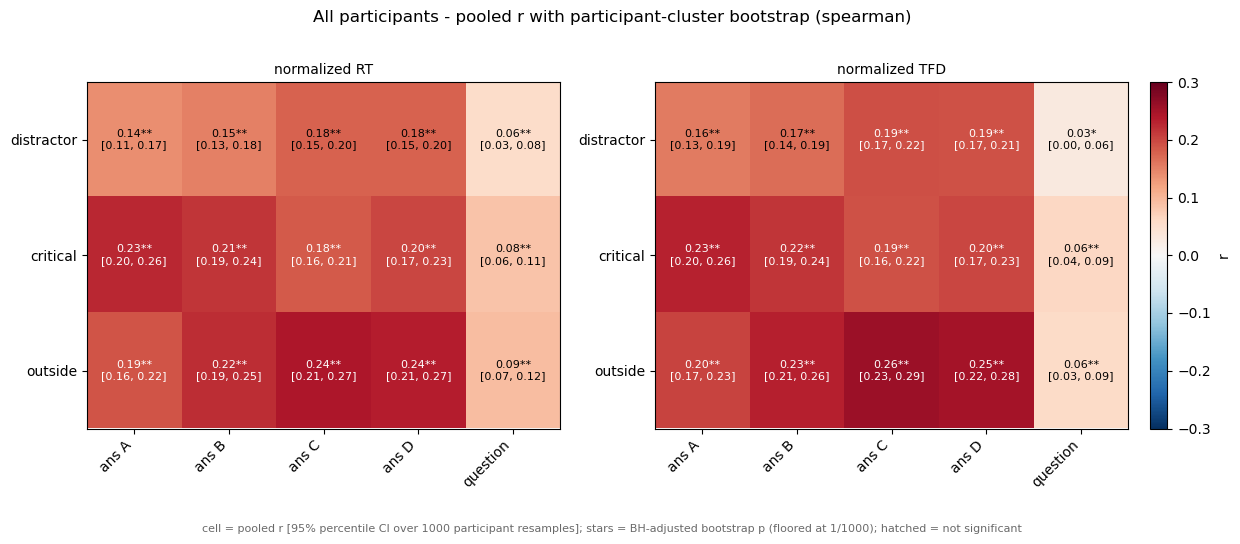

(<Figure size 1400x450 with 3 Axes>,
 array([<Axes: title={'center': 'normalized RT'}>,
        <Axes: title={'center': 'normalized TFD'}>], dtype=object))

In [33]:
boot_all = bootstrap_maps(df, n_boot=1000)
plot_bootstrap_maps(boot_all, "All participants")

In [34]:
summarise_map(boot_all["RT"]).round(4)

,row,col,n,r,ci_low,ci_high,p,p_adj,stars
0,distractor,ans A,360,0.1386,0.1120,0.1680,0.001,0.001,**
1,distractor,ans B,360,0.1511,0.1267,0.1768,0.001,0.001,**
2,distractor,ans C,360,0.1762,0.1511,0.2011,0.001,0.001,**
3,distractor,ans D,360,0.1774,0.1519,0.2020,0.001,0.001,**
4,distractor,question,360,0.0552,0.0324,0.0789,0.001,0.001,**
5,critical,ans A,360,0.2260,0.1977,0.2562,0.001,0.001,**
6,critical,ans B,360,0.2135,0.1891,0.2383,0.001,0.001,**
7,critical,ans C,360,0.1832,0.1579,0.2100,0.001,0.001,**
8,critical,ans D,360,0.1997,0.1743,0.2277,0.001,0.001,**
9,critical,question,360,0.0848,0.0631,0.1086,0.001,0.001,**


#### Per group

Same bootstrap within each reading regime. Half the participants each, so the
intervals come out roughly sqrt(2) wider than the all-participants ones above --
that widening is expected and is not evidence of a weaker effect. Whether a cell
actually *differs* between the groups is `group_contrast` above, not an eyeball
comparison of these two figures.

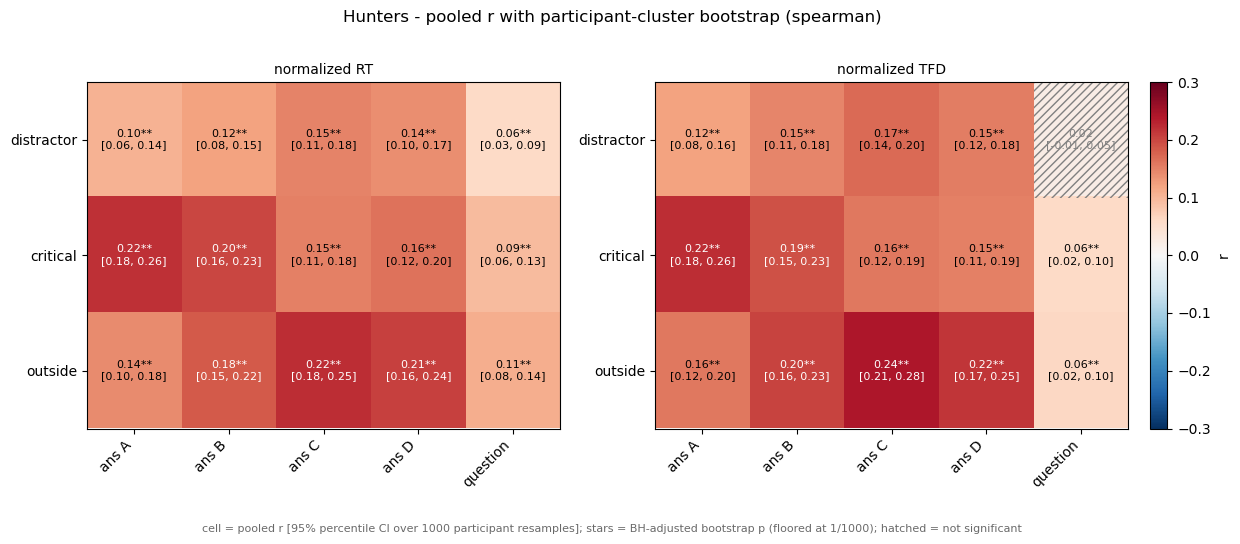

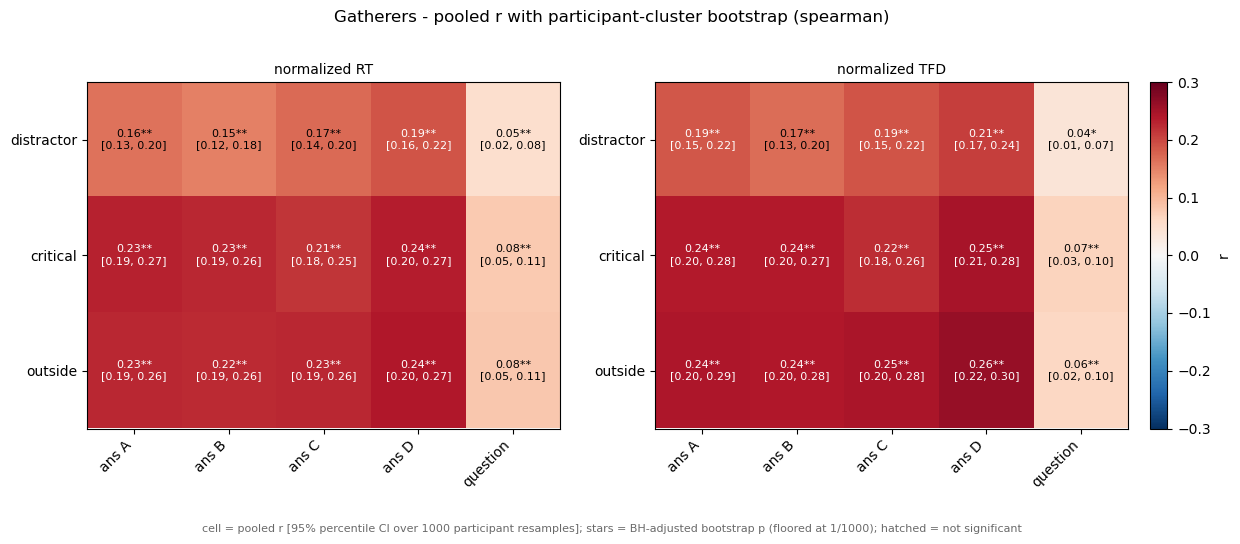

In [35]:
boot_by_group = group_bootstrap_maps(group_dfs, n_boot=1000)

vmax = shared_vmax(boot_by_group)
for name, boot in boot_by_group.items():
    plot_bootstrap_maps(boot, name.capitalize(), vmax=vmax)

### Focus: critical -> answer A

Two questions about the `critical` row specifically, both on the participant-level
Fisher z (the pooled r and its bootstrap are descriptive; these are the tests).

1. Is `critical -> ans A` stronger than `critical -> ` anything else, for all
   participants and within each regime?
2. Do the `critical` effects differ between hunters and gatherers?

Correction is applied within each family separately -- the 4 contrasts of
question 1 per participant set, and the 5 critical cells of question 2 -- rather
than across everything computed in this notebook.

In [36]:
# 1. critical -> ans A against the other answers in the same row.
focus_stats = {"all": stats_all, **stats_by_group}
crit_vs_rest = reference_contrasts(focus_stats, region="critical", answer="answer_A", metric='RT')
crit_vs_rest.round(4)

,label,cell_a,cell_b,n,r_a,r_b,delta_r,delta_z,ci_low,ci_high,t,p,d,p_adj,sig,stars
0,all,RT_normalized_critical ~ RT_normalized_answer_A,RT_normalized_critical ~ RT_normalized_question,360,0.0951,0.0532,0.0419,0.0422,0.0223,0.0620,4.1781,0.0000,0.2202,0.0001,True,***
1,all,RT_normalized_critical ~ RT_normalized_answer_A,RT_normalized_critical ~ RT_normalized_answer_C,360,0.0951,0.0609,0.0343,0.0345,0.0177,0.0512,4.0480,0.0001,0.2133,0.0001,True,***
2,all,RT_normalized_critical ~ RT_normalized_answer_A,RT_normalized_critical ~ RT_normalized_answer_D,360,0.0951,0.0628,0.0324,0.0326,0.0159,0.0492,3.8419,0.0001,0.2025,0.0002,True,***
3,all,RT_normalized_critical ~ RT_normalized_answer_A,RT_normalized_critical ~ RT_normalized_answer_B,360,0.0951,0.1055,-0.0104,-0.0105,-0.0266,0.0056,-1.2863,0.1992,-0.0678,0.1992,False,
4,gatherers,RT_normalized_critical ~ RT_normalized_answer_A,RT_normalized_critical ~ RT_normalized_question,180,0.0857,0.0327,0.0530,0.0532,0.0254,0.0811,3.7673,0.0002,0.2808,0.0009,True,***
5,gatherers,RT_normalized_critical ~ RT_normalized_answer_A,RT_normalized_critical ~ RT_normalized_answer_C,180,0.0857,0.0641,0.0216,0.0217,-0.0025,0.0459,1.7680,0.0788,0.1318,0.1575,False,
6,gatherers,RT_normalized_critical ~ RT_normalized_answer_A,RT_normalized_critical ~ RT_normalized_answer_D,180,0.0857,0.0730,0.0127,0.0128,-0.0118,0.0375,1.0271,0.3058,0.0766,0.4077,False,
7,gatherers,RT_normalized_critical ~ RT_normalized_answer_A,RT_normalized_critical ~ RT_normalized_answer_B,180,0.0857,0.0938,-0.0081,-0.0082,-0.0314,0.0150,-0.6952,0.4878,-0.0518,0.4878,False,
8,hunters,RT_normalized_critical ~ RT_normalized_answer_A,RT_normalized_critical ~ RT_normalized_answer_D,180,0.1045,0.0525,0.0520,0.0523,0.0300,0.0746,4.6243,0.0000,0.3447,0.0000,True,***
9,hunters,RT_normalized_critical ~ RT_normalized_answer_A,RT_normalized_critical ~ RT_normalized_answer_C,180,0.1045,0.0576,0.0469,0.0472,0.0240,0.0704,4.0167,0.0001,0.2994,0.0002,True,***


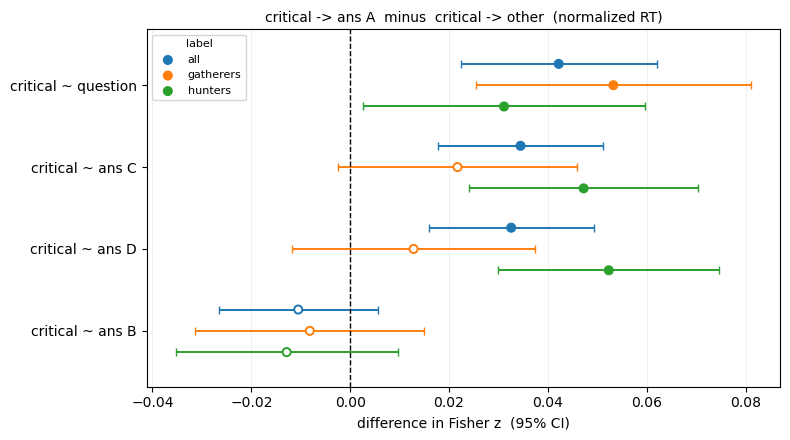

<Axes: title={'center': 'critical -> ans A  minus  critical -> other  (normalized RT)'}, xlabel='difference in Fisher z  (95% CI)'>

In [37]:

# Positive delta = the reference (critical -> ans A) is the stronger correlation.
# Filled marker = the interval clears 0.
plot_contrasts(
    crit_vs_rest,
    title="critical -> ans A  minus  critical -> other  (normalized RT)",
    group_col="label",
    xlabel="difference in Fisher z  (95% CI)",
)

### Do the critical effects differ by regime?

Welch two-sample t-test per cell on the per-participant z, restricted to the
`critical` row so the correction family is those 5 cells.

In [38]:
crit_by_group = group_contrast(stats_by_group, "RT", region="critical")
crit_by_group.round(4)

,row,col,n_hunters,n_gatherers,r_hunters,r_gatherers,delta_r,delta_z,ci_low,ci_high,t,p,d,p_adj,sig,stars
0,RT_normalized_critical,RT_normalized_answer_A,180,180,0.1045,0.0857,0.0188,0.0190,-0.0108,0.0488,1.2528,0.2111,0.1321,0.2639,False,
1,RT_normalized_critical,RT_normalized_answer_B,180,180,0.1172,0.0938,0.0234,0.0237,-0.0066,0.0540,1.5362,0.1254,0.1619,0.2639,False,
2,RT_normalized_critical,RT_normalized_answer_C,180,180,0.0576,0.0641,-0.0065,-0.0065,-0.0358,0.0227,-0.4402,0.6601,-0.0464,0.6601,False,
3,RT_normalized_critical,RT_normalized_answer_D,180,180,0.0525,0.0730,-0.0204,-0.0205,-0.0512,0.0102,-1.3132,0.1900,-0.1384,0.2639,False,
4,RT_normalized_critical,RT_normalized_question,180,180,0.0736,0.0327,0.0410,0.0411,0.0100,0.0722,2.5998,0.0097,0.2740,0.0486,True,*


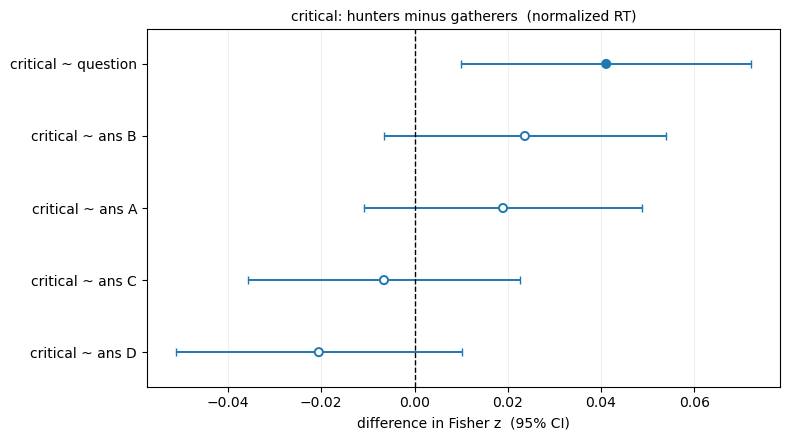

<Axes: title={'center': 'critical: hunters minus gatherers  (normalized RT)'}, xlabel='difference in Fisher z  (95% CI)'>

In [39]:
plot_contrasts(
    crit_by_group,
    title="critical: hunters minus gatherers  (normalized RT)",
    xlabel="difference in Fisher z  (95% CI)",
)

### Dwell proportions instead of reading times

Everything above is about *how long*. The same two screens also have a *share*
description: what fraction of the trial's dwell time went where. The answer
screen already carries it -- `area_dwell_proportion__answer_A` ... `__question`,
each area's dwell time over the trial's total, from `create_dwell_proportions`
in the data prep. The paragraph screen has exactly the same quantity per span,
built the same way by `answer_RTs.features._dwell_proportion` and cached in
`L1_paragraph_span_features.csv` -- it is simply not in the model-ready file the
maps above run on. `load_*_proportion_features` merges the three text shares in
(all 19,436 trials match) and drops the 9 trials with no answer-screen dwell at
all, where the five answer shares are all 0.

The map is then 3 text shares x 5 answer shares, through the same
participant-level machinery as before: within-participant Spearman r, Fisher z,
one-sample t-test across the participants, BH-corrected over the 15 cells. Same
three versions as above -- all participants, hunters, gatherers.

Two things to keep in mind:

- **Each side is compositional.** The three text shares sum to 1 and so do the
  five answer shares, so within a side the parts are negatively coupled by
  construction: a larger share for the critical span is a smaller share for the
  rest, whatever the answer screen does. Each cell is still an ordinary
  correlation, but the signs along a row are not free to all agree, and a
  negative cell can be the mirror image of a positive one elsewhere in the row.
- **This is a different question from the RT maps.** There, most of what both
  columns shared was "this trial was slow" -- which is why the pooled r ran at
  about twice the participant-level r. Taking shares divides that common factor
  out on each screen separately, and the two estimands then nearly coincide
  (`r` vs `r_pooled` below). What is left is allocation against allocation.

In [40]:
from src.statistics.RT_correlations import (
    load_all_proportion_features,
    load_group_proportion_features,
    proportion_map_stats,
    group_proportion_map_stats,
    plot_proportion_maps,
    proportion_region_contrasts,
    proportion_group_contrast,
    proportion_summary,
    pretty_labels,
)

# Same feature frames as above, plus the three text dwell proportions merged in
# from the cached paragraph-span features.
prop_df = load_all_proportion_features()
prop_group_dfs = load_group_proportion_features()

# Sanity check on the shares: each side should average out to 1 across its parts
# (3 text spans, 5 answer areas).
proportion_summary(prop_df).round(3)

all: (19436, 214)
text dwell proportions: 19436/19436 trials matched
dropping 9 trials with no answer-screen dwell
hunters: (9719, 214)
text dwell proportions: 9719/9719 trials matched
dropping 5 trials with no answer-screen dwell
gatherers: (9717, 214)
text dwell proportions: 9717/9717 trials matched
dropping 4 trials with no answer-screen dwell


,count,mean,std,min,50%,max
area_dwell_proportion__distractor,19427.0,0.124,0.106,0.0,0.095,0.853
area_dwell_proportion__critical,19427.0,0.339,0.167,0.0,0.314,1.000
area_dwell_proportion__outside,19427.0,0.537,0.188,0.0,0.548,1.000
area_dwell_proportion__answer_A,19427.0,0.323,0.142,0.0,0.313,1.000
area_dwell_proportion__answer_B,19427.0,0.233,0.118,0.0,0.221,1.000
area_dwell_proportion__answer_C,19427.0,0.209,0.109,0.0,0.199,1.000
area_dwell_proportion__answer_D,19427.0,0.184,0.095,0.0,0.174,1.000
area_dwell_proportion__question,19427.0,0.051,0.077,0.0,0.029,1.000


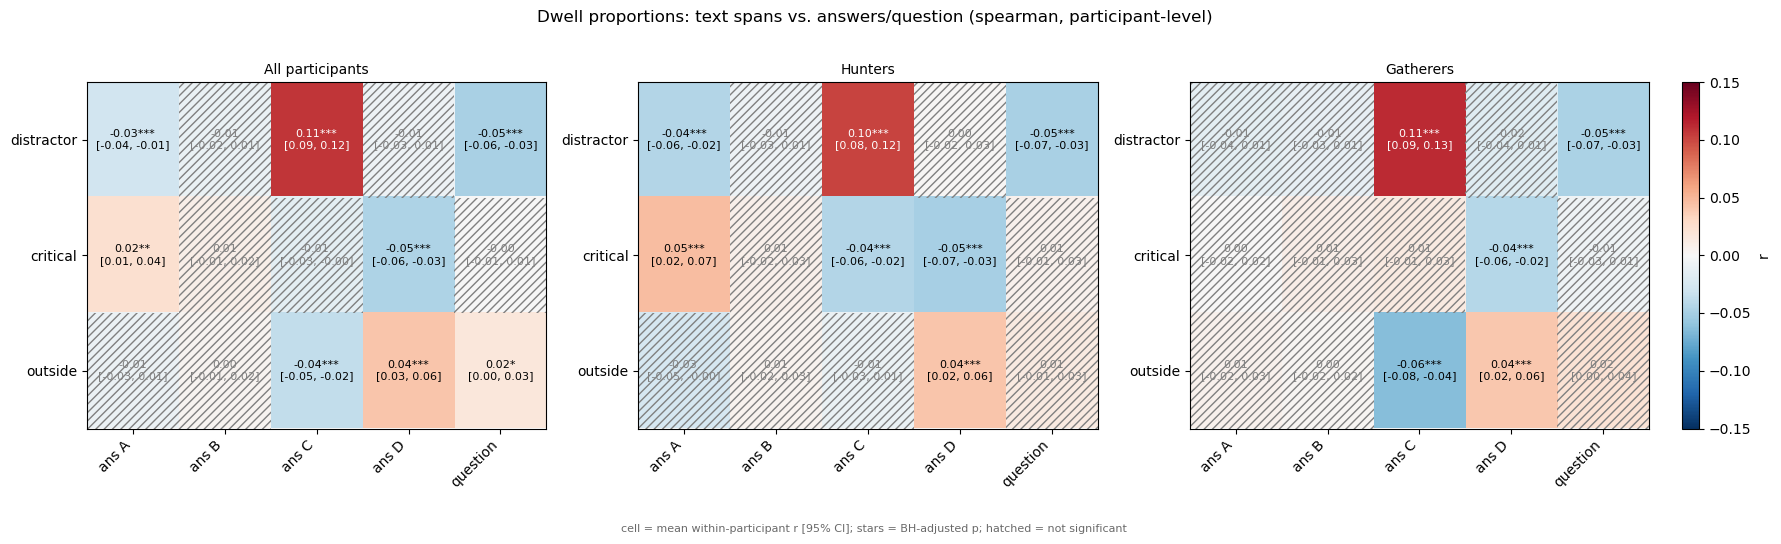

(<Figure size 2100x450 with 4 Axes>,
 array([<Axes: title={'center': 'All participants'}>,
        <Axes: title={'center': 'Hunters'}>,
        <Axes: title={'center': 'Gatherers'}>], dtype=object))

In [ ]:
# All three versions of the map, on one shared colour scale.
prop_stats = proportion_map_stats(prop_df)
prop_stats_by_group = group_proportion_map_stats(prop_group_dfs)

prop_stats_by_label = {
    "All participants": prop_stats,
    "Hunters": prop_stats_by_group["hunters"],
    "Gatherers": prop_stats_by_group["gatherers"],
}
plot_proportion_maps(prop_stats_by_label, show_ci=True)

#add this to corr pred model

In [42]:
# Per-cell numbers, all participants. `r` and `r_pooled` sit on top of each
# other here, unlike the RT maps -- see the note above.
summarise_map(prop_stats).round(4)

,row,col,n,r,ci_low,ci_high,d,t,p,p_adj,stars,r_pooled
0,distractor,ans C,360,0.1068,0.0925,0.1210,0.7693,14.5956,0.0000,0.0000,***,0.1092
1,distractor,question,360,-0.0486,-0.0633,-0.0338,-0.3413,-6.4753,0.0000,0.0000,***,-0.0492
2,critical,ans D,360,-0.0464,-0.0608,-0.0321,-0.3358,-6.3710,0.0000,0.0000,***,-0.0495
3,outside,ans D,360,0.0412,0.0264,0.0559,0.2894,5.4907,0.0000,0.0000,***,0.0441
4,outside,ans C,360,-0.0368,-0.0513,-0.0222,-0.2610,-4.9512,0.0000,0.0000,***,-0.0208
5,distractor,ans A,360,-0.0292,-0.0442,-0.0142,-0.2020,-3.8326,0.0001,0.0004,***,-0.0343
6,critical,ans A,360,0.0238,0.0090,0.0386,0.1664,3.1572,0.0017,0.0037,**,0.0521
7,outside,question,360,0.0174,0.0034,0.0313,0.1287,2.4421,0.0151,0.0283,*,0.0054
8,critical,ans C,360,-0.0147,-0.0290,-0.0005,-0.1069,-2.0288,0.0432,0.0720,.,-0.0331
9,distractor,ans B,360,-0.0096,-0.0247,0.0055,-0.0662,-1.2551,0.2102,0.3154,,-0.0081


### Spans against each other, and the two regimes against each other

The same two tests as for the RT maps, on the same per-participant z: the three
spans pairwise within each answer column (15 paired tests), and hunters vs.
gatherers cell by cell (15 Welch tests).

In [43]:
proportion_region_contrasts(prop_stats).round(4)

,cell_a,cell_b,n,r_a,r_b,delta_r,delta_z,ci_low,ci_high,t,p,d,p_adj,sig,stars
0,area_dwell_proportion__distractor ~ area_dwell...,area_dwell_proportion__critical ~ area_dwell_p...,360,0.1068,-0.0147,0.1215,0.1219,0.1017,0.1420,11.8975,0.0000,0.6271,0.0000,True,***
1,area_dwell_proportion__distractor ~ area_dwell...,area_dwell_proportion__outside ~ area_dwell_pr...,360,0.1068,-0.0368,0.1435,0.1440,0.1190,0.1689,11.3436,0.0000,0.5979,0.0000,True,***
2,area_dwell_proportion__critical ~ area_dwell_p...,area_dwell_proportion__outside ~ area_dwell_pr...,360,-0.0464,0.0412,-0.0876,-0.0877,-0.1152,-0.0601,-6.2618,0.0000,-0.3300,0.0000,True,***
3,area_dwell_proportion__distractor ~ area_dwell...,area_dwell_proportion__critical ~ area_dwell_p...,360,-0.0292,0.0238,-0.0530,-0.0530,-0.0726,-0.0335,-5.3364,0.0000,-0.2813,0.0000,True,***
4,area_dwell_proportion__distractor ~ area_dwell...,area_dwell_proportion__outside ~ area_dwell_pr...,360,-0.0486,0.0174,-0.0659,-0.0660,-0.0908,-0.0412,-5.2341,0.0000,-0.2759,0.0000,True,***
5,area_dwell_proportion__distractor ~ area_dwell...,area_dwell_proportion__critical ~ area_dwell_p...,360,-0.0486,-0.0001,-0.0485,-0.0485,-0.0685,-0.0285,-4.7707,0.0000,-0.2514,0.0000,True,***
6,area_dwell_proportion__distractor ~ area_dwell...,area_dwell_proportion__outside ~ area_dwell_pr...,360,-0.0081,0.0412,-0.0493,-0.0493,-0.0770,-0.0216,-3.5022,0.0005,-0.1846,0.0011,True,**
7,area_dwell_proportion__distractor ~ area_dwell...,area_dwell_proportion__critical ~ area_dwell_p...,360,-0.0081,-0.0464,0.0383,0.0383,0.0163,0.0604,3.4213,0.0007,0.1803,0.0013,True,**
8,area_dwell_proportion__critical ~ area_dwell_p...,area_dwell_proportion__outside ~ area_dwell_pr...,360,0.0238,-0.0093,0.0331,0.0331,0.0032,0.0629,2.1798,0.0299,0.1149,0.0499,True,*
9,area_dwell_proportion__distractor ~ area_dwell...,area_dwell_proportion__critical ~ area_dwell_p...,360,-0.0096,0.0089,-0.0185,-0.0185,-0.0393,0.0023,-1.7528,0.0805,-0.0924,0.1207,False,


In [44]:
prop_by_group = proportion_group_contrast(prop_stats_by_group)

# The full `area_dwell_proportion__` names make the table unreadable; the plot
# below shortens them the same way.
prop_by_group.assign(
    row=pretty_labels(prop_by_group["row"]),
    col=pretty_labels(prop_by_group["col"]),
).round(4)

,row,col,n_hunters,n_gatherers,r_hunters,r_gatherers,delta_r,delta_z,ci_low,ci_high,t,p,d,p_adj,sig,stars
0,distractor,ans A,180,180,-0.0436,-0.0148,-0.0287,-0.0288,-0.0587,0.0011,-1.8925,0.0592,-0.1995,0.1777,False,
1,distractor,ans B,180,180,-0.0075,-0.0117,0.0042,0.0042,-0.0260,0.0345,0.2741,0.7842,0.0289,0.9367,False,
2,distractor,ans C,180,180,0.1018,0.1118,-0.0100,-0.0101,-0.0390,0.0188,-0.6890,0.4913,-0.0726,0.9212,False,
3,distractor,ans D,180,180,0.0022,-0.0185,0.0207,0.0207,-0.0132,0.0547,1.2022,0.2301,0.1267,0.5752,False,
4,distractor,question,180,180,-0.0492,-0.0480,-0.0012,-0.0012,-0.0308,0.0284,-0.0795,0.9367,-0.0084,0.9367,False,
5,critical,ans A,180,180,0.0466,0.0010,0.0457,0.0457,0.0164,0.0750,3.0651,0.0023,0.3231,0.0117,True,*
6,critical,ans B,180,180,0.0076,0.0101,-0.0025,-0.0025,-0.0330,0.0280,-0.1616,0.8717,-0.0170,0.9367,False,
7,critical,ans C,180,180,-0.0434,0.0140,-0.0575,-0.0575,-0.0854,-0.0295,-4.0432,0.0001,-0.4262,0.0010,True,***
8,critical,ans D,180,180,-0.0496,-0.0433,-0.0063,-0.0064,-0.0351,0.0224,-0.4349,0.6639,-0.0458,0.9367,False,
9,critical,question,180,180,0.0060,-0.0062,0.0122,0.0122,-0.0152,0.0396,0.8770,0.3811,0.0924,0.8166,False,


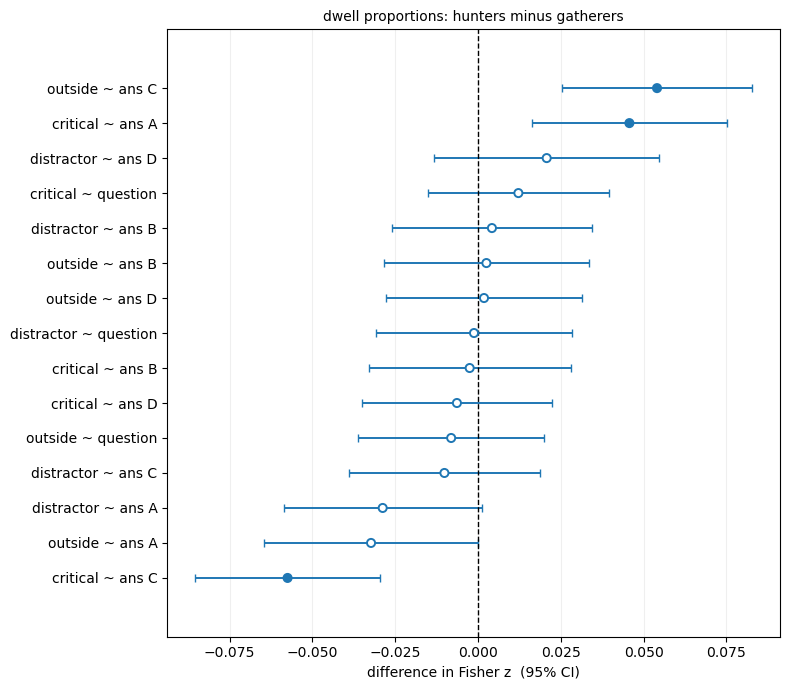

<Axes: title={'center': 'dwell proportions: hunters minus gatherers'}, xlabel='difference in Fisher z  (95% CI)'>

In [45]:
plot_contrasts(
    prop_by_group,
    title="dwell proportions: hunters minus gatherers",
    xlabel="difference in Fisher z  (95% CI)",
    figsize=(8, 7),
)